In [6]:
import ksz2p1d

In [7]:
kszobj = ksz2p1d.ksz2p1d_obj()

In [8]:
output_dir = '/scratch2/acmlai/ksz_pipeline/pz0.06/'
kszobj.init(output_dir)
# kszobj.output_dir = output_dir
kszobj.desi_dir = '/scratch2/acmlai/ksz_pipeline/pz0.06/desilrg_skyregionNS_pzcut0.08_zmin0.4_zmax1.1_nbins20/'

configuring to the desi directory: /scratch2/acmlai/ACTDR6/ksz2p1d_test/desi_inputs/
found lrg catalog, will be loaded
found associated photo-z catalog, will be loaded
found associated pixel weight catalog, will be loaded
found associated random catalog, will be loaded
loading catalogue from the desi directory...
Apply veto mask:  True
now loading random catalog...
no. of objects remaining in the catalog:  27790274
object catalog same size as photon-z catalog?  True
object catalog keys:  ['TARGETID', 'RA', 'DEC', 'EBV', 'PIXEL_NOBS_G', 'PIXEL_NOBS_R', 'PIXEL_NOBS_Z', 'MASKBITS', 'PHOTSYS', 'Z_PHOT_MEDIAN', 'lrg_mask', 'pz_bin']
photo-z catalog keys:  ['Z_PHOT_MEAN', 'Z_PHOT_MEDIAN', 'Z_PHOT_STD', 'Z_PHOT_L68', 'Z_PHOT_U68', 'Z_PHOT_L95', 'Z_PHOT_U95', 'Z_SPEC', 'SURVEY', 'TRAINING']
random catalog keys:  ['HPXPIXEL', 'RA', 'DEC', 'n_randoms', 'FRACAREA', 'EBV', 'GALDEPTH_G', 'GALDEPTH_R', 'GALDEPTH_Z', 'PSFDEPTH_G', 'PSFDEPTH_R', 'PSFDEPTH_Z', 'PSFDEPTH_W1', 'PSFDEPTH_W2', 'PSFSIZE_G',

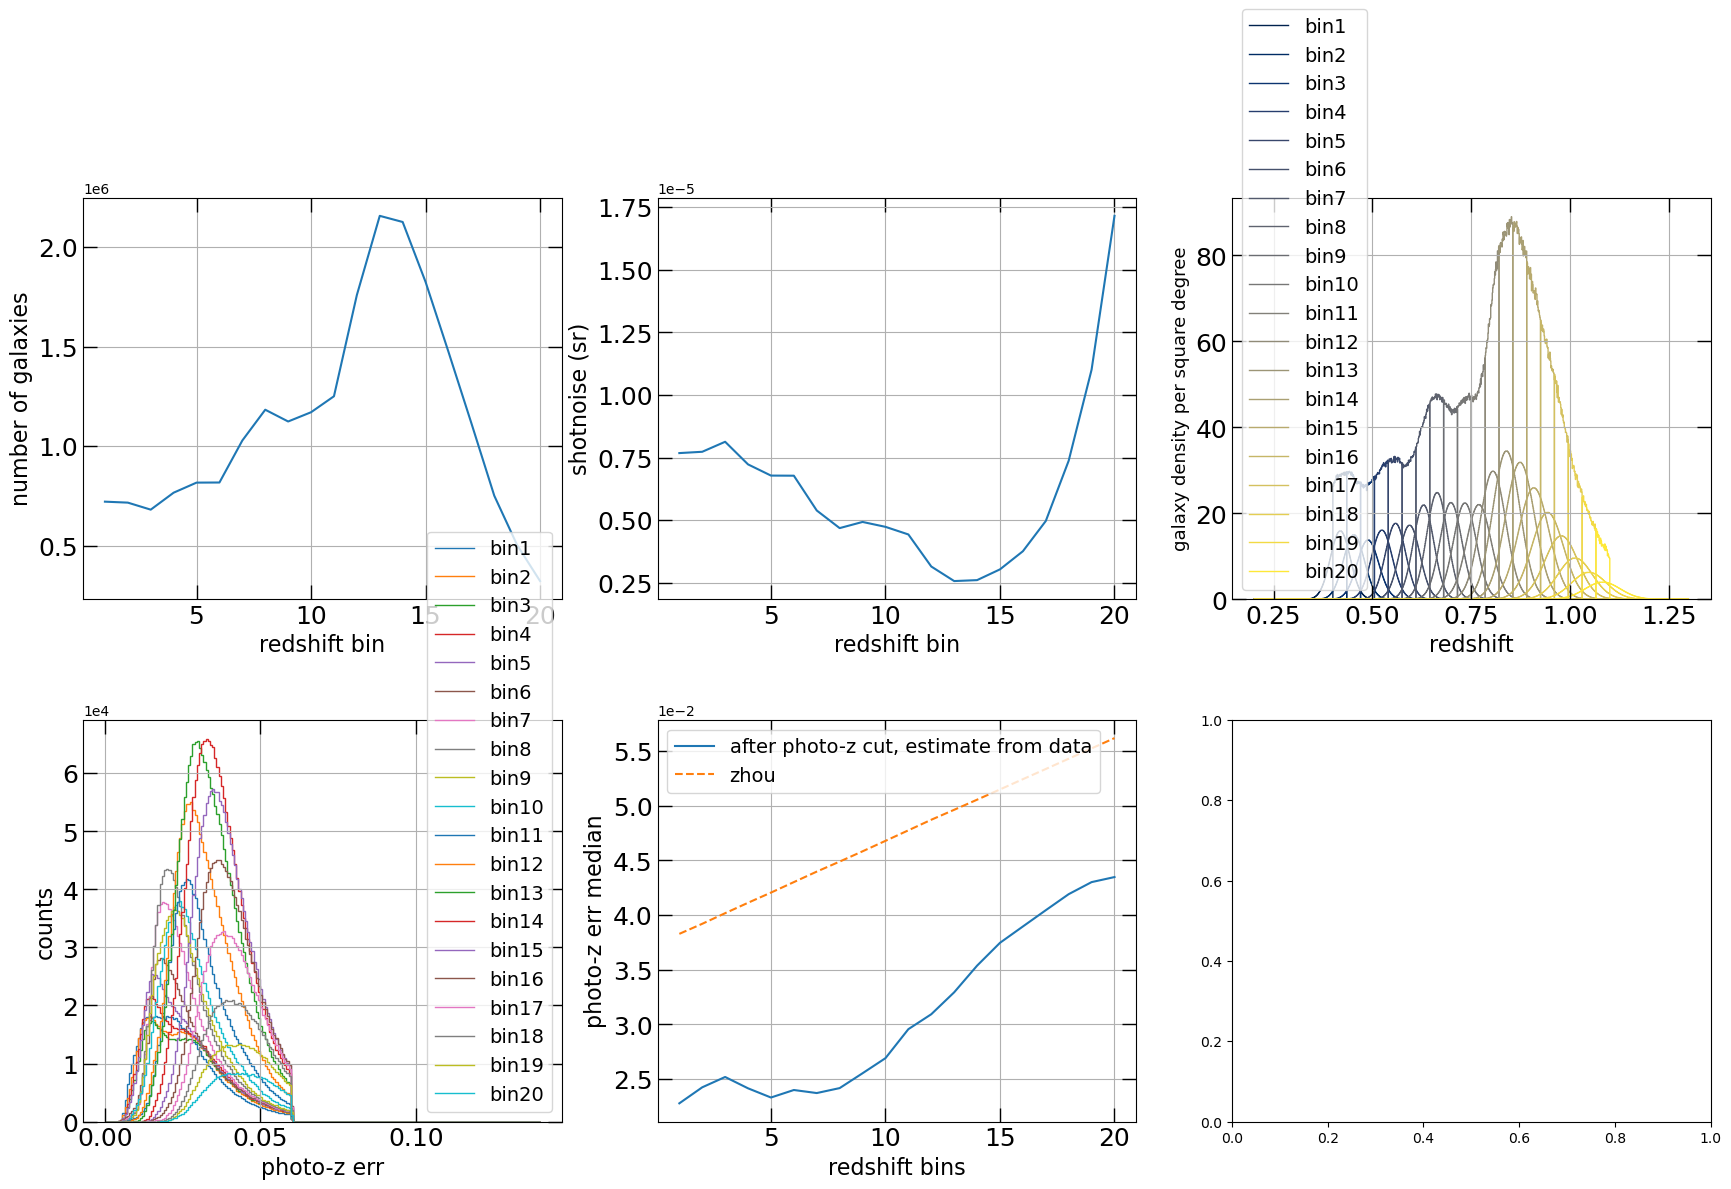

Availble properties:
index 2:  EBV
index 3:  PSFDEPTH_W1
index 4:  GALDEPTH_G
index 5:  GALDEPTH_R
index 6:  GALDEPTH_Z
index 7:  PSFDEPTH_G
index 8:  PSFDEPTH_R
index 9:  PSFDEPTH_Z
index 10:  PSFSIZE_G
index 11:  PSFSIZE_R
index 12:  PSFSIZE_Z
index 13:  STARDENS
you can select them by calling this function again with a boolean mask as argument (0 means not using), otherwise all of them will be used
Currently applied imaging properties:  ['EBV', 'PSFDEPTH_W1', 'GALDEPTH_G', 'GALDEPTH_R', 'GALDEPTH_Z', 'PSFDEPTH_G', 'PSFDEPTH_R', 'PSFDEPTH_Z', 'PSFSIZE_G', 'PSFSIZE_R', 'PSFSIZE_Z', 'STARDENS']
Availble properties:
index 2:  EBV
index 3:  PSFDEPTH_W1
index 4:  GALDEPTH_G
index 5:  GALDEPTH_R
index 6:  GALDEPTH_Z
index 7:  PSFDEPTH_G
index 8:  PSFDEPTH_R
index 9:  PSFDEPTH_Z
index 10:  PSFSIZE_G
index 11:  PSFSIZE_R
index 12:  PSFSIZE_Z
index 13:  STARDENS
you can select them by calling this function again with a boolean mask as argument (0 means not using), otherwise all of them will b

In [ ]:
kszobj.init_desi(sigma_z_cut = 0.06, pz_type='from_cuts')
kszobj.run_desi()

In [ ]:
kszobj.run_bias()

In [ ]:
kszobj.run_Cgtau_fiducials()

In [ ]:
Tmask_fname = '/scratch2/acmlai/ACTDR6/ksz2p1d_test/Tmaps/Tmap_nilc_skymasked/mask_nside4096.fits'
gmask_fname = '/scratch2/acmlai/ACTDR6/masks/desi_mask_nside4096_binary.fits'
overlap_in_fname = '/scratch2/acmlai/ACTDR6/masks/overlap_ACTDR6nilc_tszmasked_desilrg_binary_nside4096.fits'
overlap_out_fname = '/scratch2/acmlai/ACTDR6/masks/overlap_ACTDR6nilc_tszmasked_desilrg_binary_nside128.fits'

Tmap_dir = '/scratch2/acmlai/ACTDR6/ksz2p1d_test/Tmaps/'

kszobj.init_qe(Tmask_fname=Tmask_fname, gmask_fname = gmask_fname, overlap_in_fname=overlap_in_fname,
              overlap_out_fname = overlap_out_fname, Tmap_dir = Tmap_dir)


In [ ]:
kszobj.run_qe(nilc=True)

In [ ]:
llow = 100
lup = 300

kszobj.get_coadd(llow, lup, nilc=True)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
Nvv_nilc = np.load(output_dir+'coadded_output.npz')['Nvvs_nilc_pcl_mean']
Nvv_coadd = np.load(output_dir+'coadded_output.npz')['Nvvs_coadd_mean']

In [ ]:
plt.semilogy(np.arange(20), Nvv_nilc, '.-', label = 'nilc')
plt.semilogy(np.arange(20), Nvv_coadd, '.-')
plt.legend()

In [ ]:
kszobj.nbins

In [ ]:
kszobj.get_qml_fiducials()

In [14]:
import numpy as np

Nf = 40
lmax = 3*32-1

f_fid = np.load(output_dir+'pyccl_fidcuial_20bins_pzcut0.06.npz')

Cdds_raw = f_fid['Cggs']
Cvvs_raw = f_fid['Cvvs']

bias = np.load(output_dir+'desilrg_skyregionNS_pzcut0.06_zmin0.4_zmax1.1_nbins20/desi_lrg_bg_pzcut1_20bins.npz')['bg']

Cggs = np.zeros((Nf//2, Nf//2, lmax+1))
Cvvs = np.zeros((Nf//2, Nf//2, lmax+1))
Cgvs = np.zeros((Nf//2, Nf//2, lmax+1))

idx = 0
for i in range(Nf//2):
    for j in range(Nf//2):
        if j >= i:
            Cggs[i,j] = Cdds_raw[idx, :lmax+1]*bias[i]*bias[j]
            Cggs[j,i] = Cggs[i,j]

            Cvvs[i,j] = Cvvs_raw[idx, :lmax+1]
            Cvvs[j,i] = Cvvs[i,j]
            idx += 1

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209


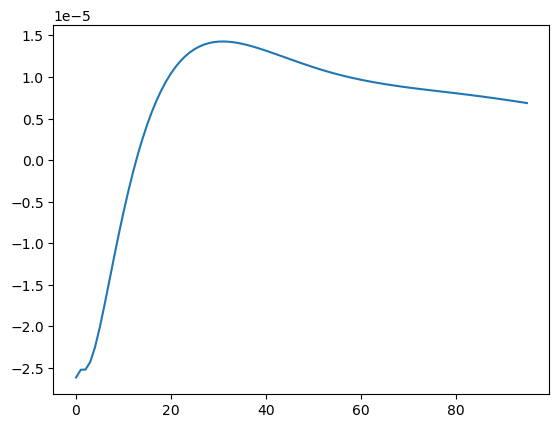

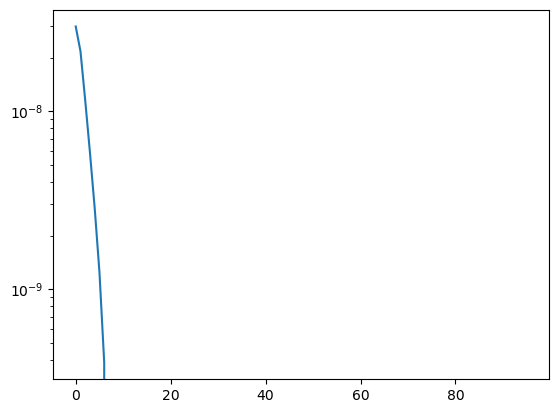

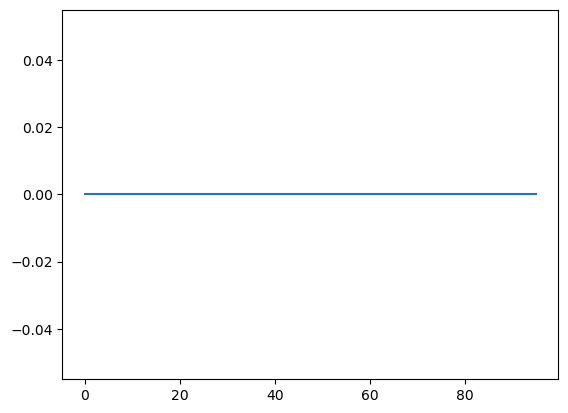

In [15]:
import matplotlib.pyplot as plt
plt.figure()
plt.plot(Cggs[0,3])

plt.figure()
plt.semilogy(Cvvs[0,3])

plt.figure()
plt.plot(Cgvs[0,0])

In [5]:
ksznoise_type = 'coadd'

kszobj.get_invcov(ksznoise_type=ksznoise_type, lcut = 7, rescale=True)

100%|███████████████████████████████████████████| 20/20 [00:03<00:00,  6.37it/s]
